In [11]:
!pip install seaborn


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# plt.style.use('seaborn')
sns.set_palette('husl')

gwo_df = pd.read_csv('metrics/gwo.csv')
pso_df = pd.read_csv('metrics/pso.csv')
ddql_df = pd.read_csv('metrics/ddql.csv')
ga_df = pd.read_csv('metrics/ga.csv')
rf_df = pd.read_csv('metrics/rf.csv')
ddql_df = pd.read_csv('metrics/ddql.csv')
mdql_df = pd.read_csv('metrics/mdql.csv')





In [10]:
def plot_metrics(metric_name, title):
    plt.figure(figsize=(12, 6))
    
    plt.plot(gwo_df[metric_name], label='GWO', alpha=0.7)
    plt.plot(pso_df[metric_name], label='PSO', alpha=0.7)
    plt.plot(ga_df[metric_name], label='GA', alpha=0.7)
    plt.plot(rf_df[metric_name], label='RF', alpha=0.7)
    plt.plot(ddql_df[metric_name], label='DDQL', alpha=0.7)
    plt.plot(mdql_df[metric_name], label='MDQL', alpha=0.7)
    
    plt.title(title)
    plt.xlabel('Iterations')
    plt.ylabel(metric_name)
    plt.legend()
    plt.grid(True)
    plt.show()
plot_metrics('reward', 'Reward Comparision Across Algorithms')
plot_metrics('loss', 'Loss Comparision Across Algorithms')
plot_metrics('accuracy', 'Accuracy Comparision Across Algorithms')
    


KeyError: 'reward'

<Figure size 1200x600 with 0 Axes>

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Interval           100 non-null    int64  
 1   Power_Consumption  100 non-null    float64
 2   CPU_Utilization    100 non-null    object 
 3   Ram_Utilization    100 non-null    object 
 4   Inactivevmids      100 non-null    object 
 5   CPU_Imbalance      100 non-null    float64
 6   Ram_Imbalance      100 non-null    float64
dtypes: float64(3), int64(1), object(3)
memory usage: 5.6+ KB

First 5 rows of the DataFrame:
   Interval  Power_Consumption  \
0         1           328.1250   
1         2           328.1250   
2         3           465.9375   
3         4           485.6250   
4         5           505.3125   

                                     CPU_Utilization  \
0  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...   
1  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,

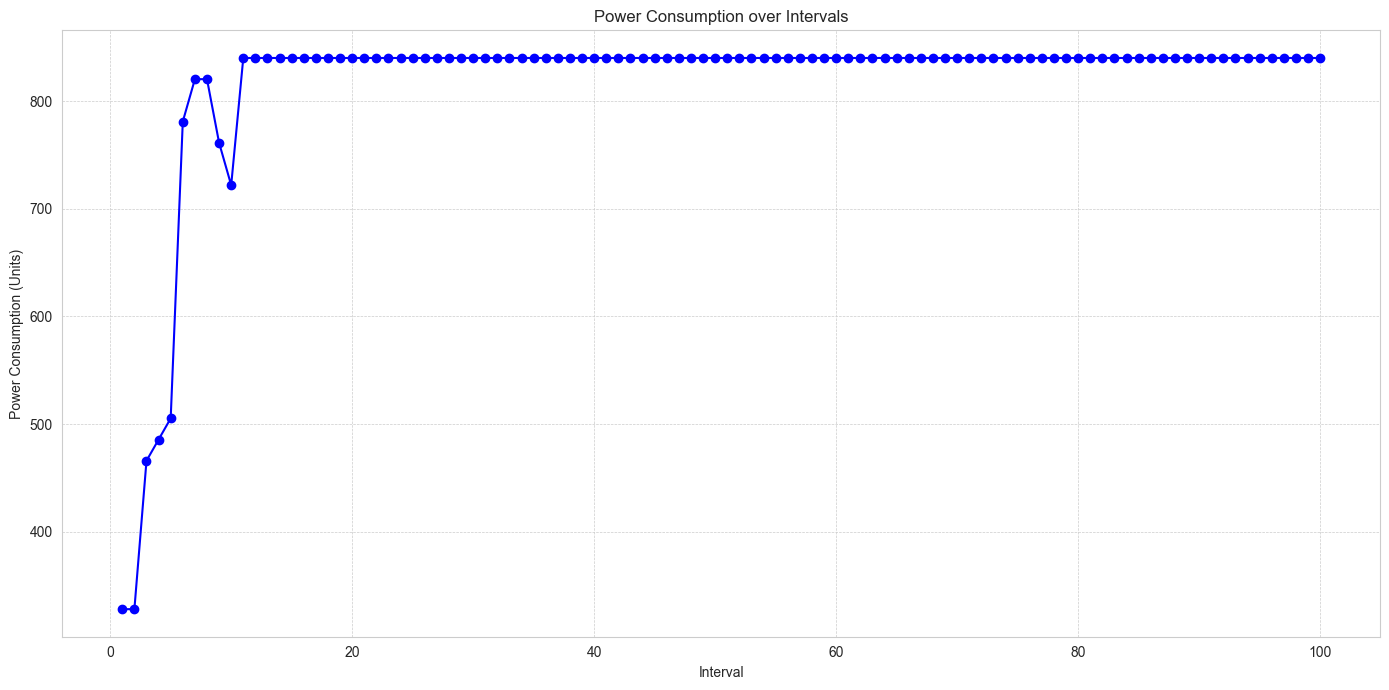

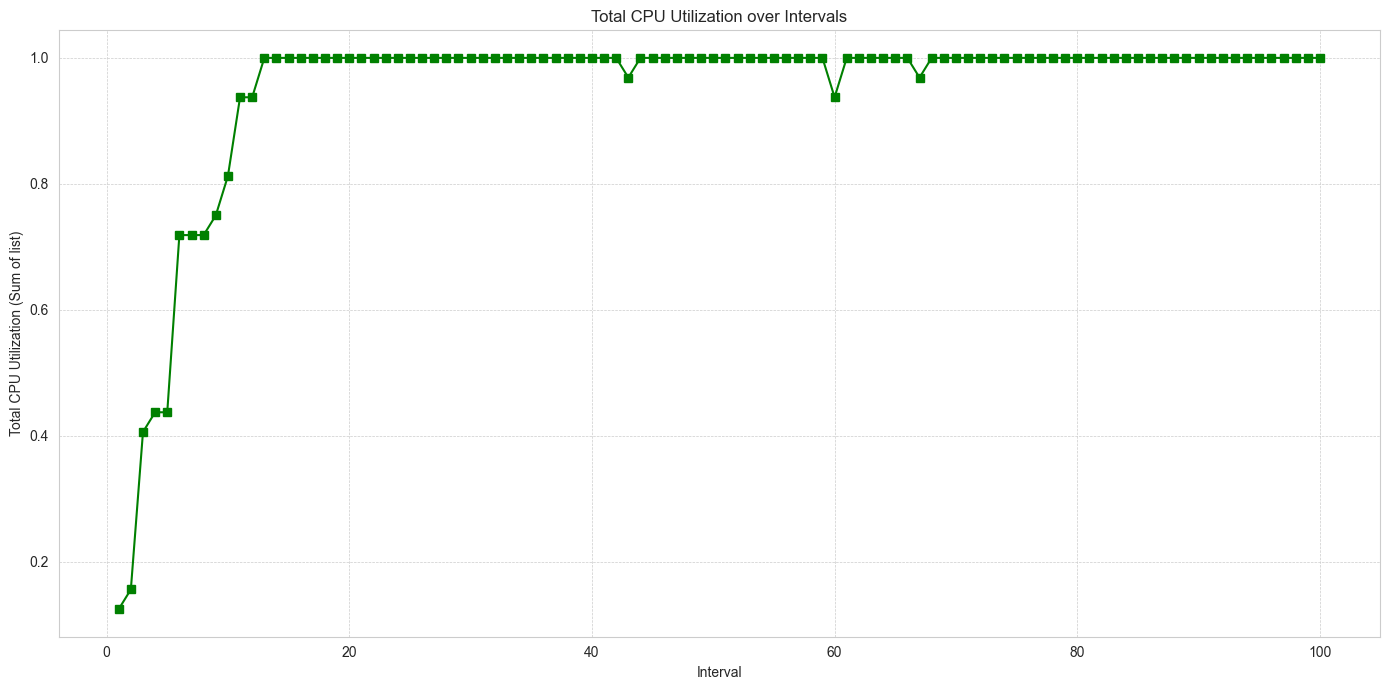

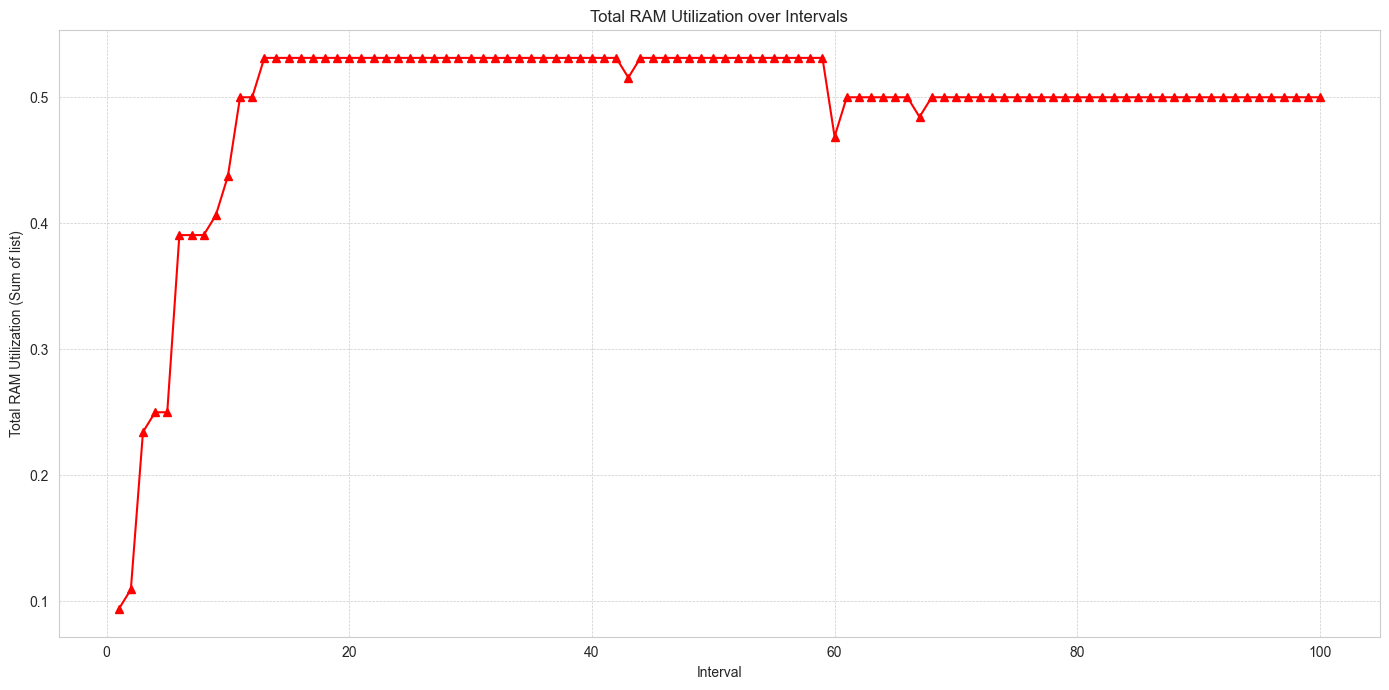

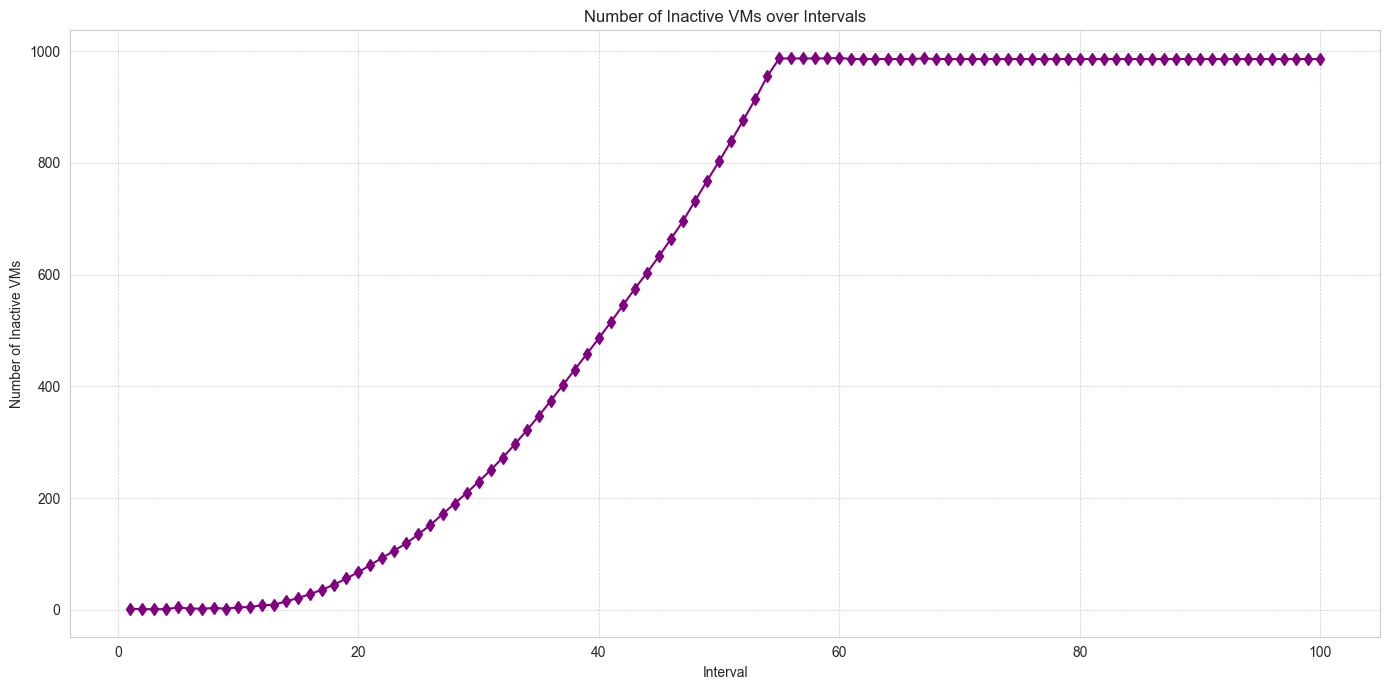

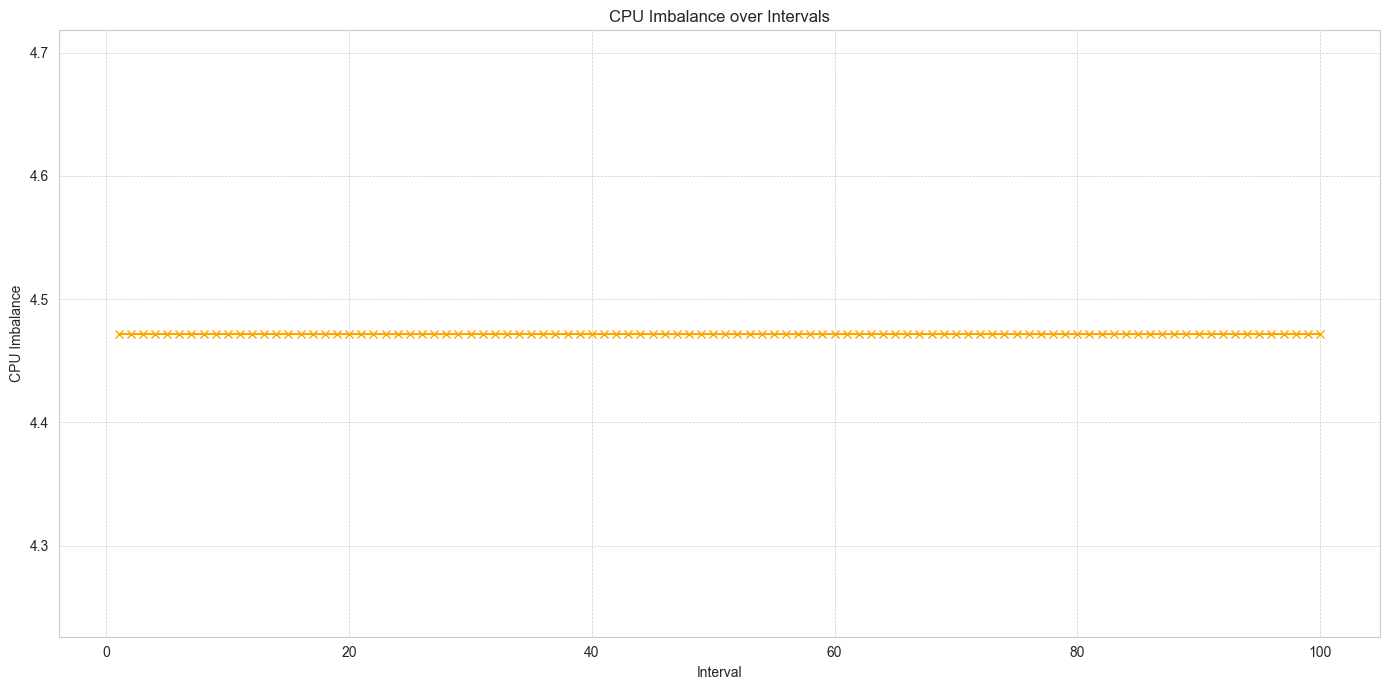

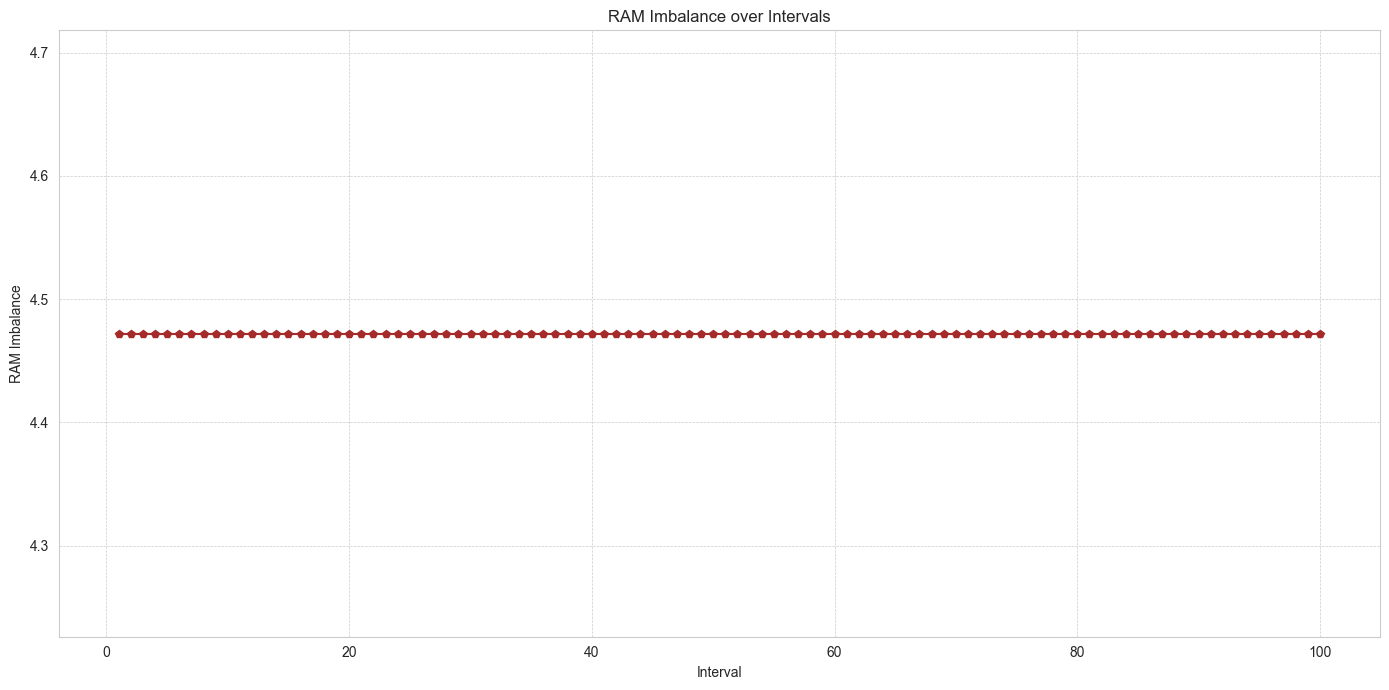

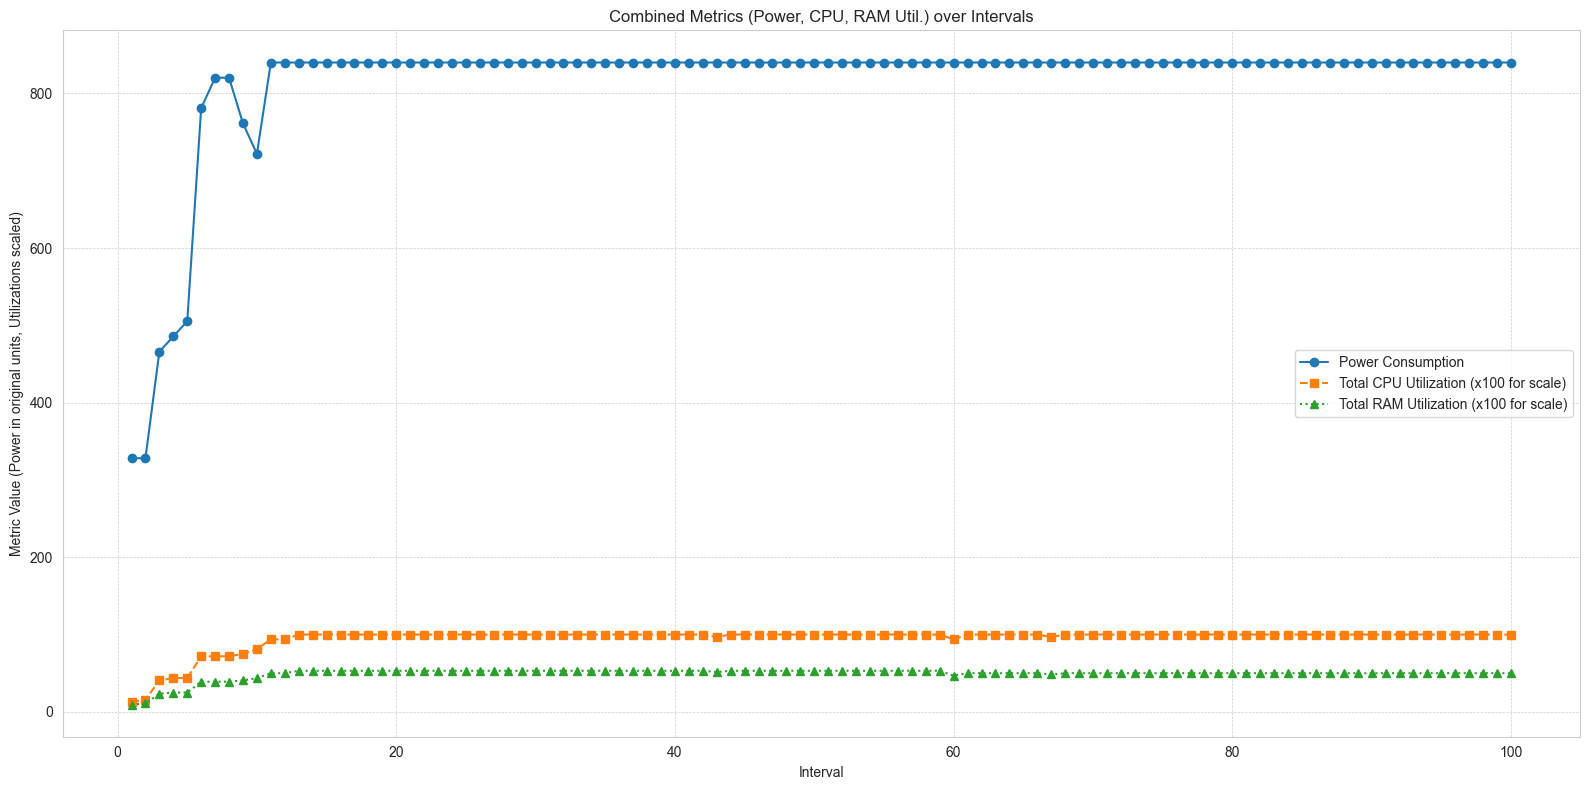

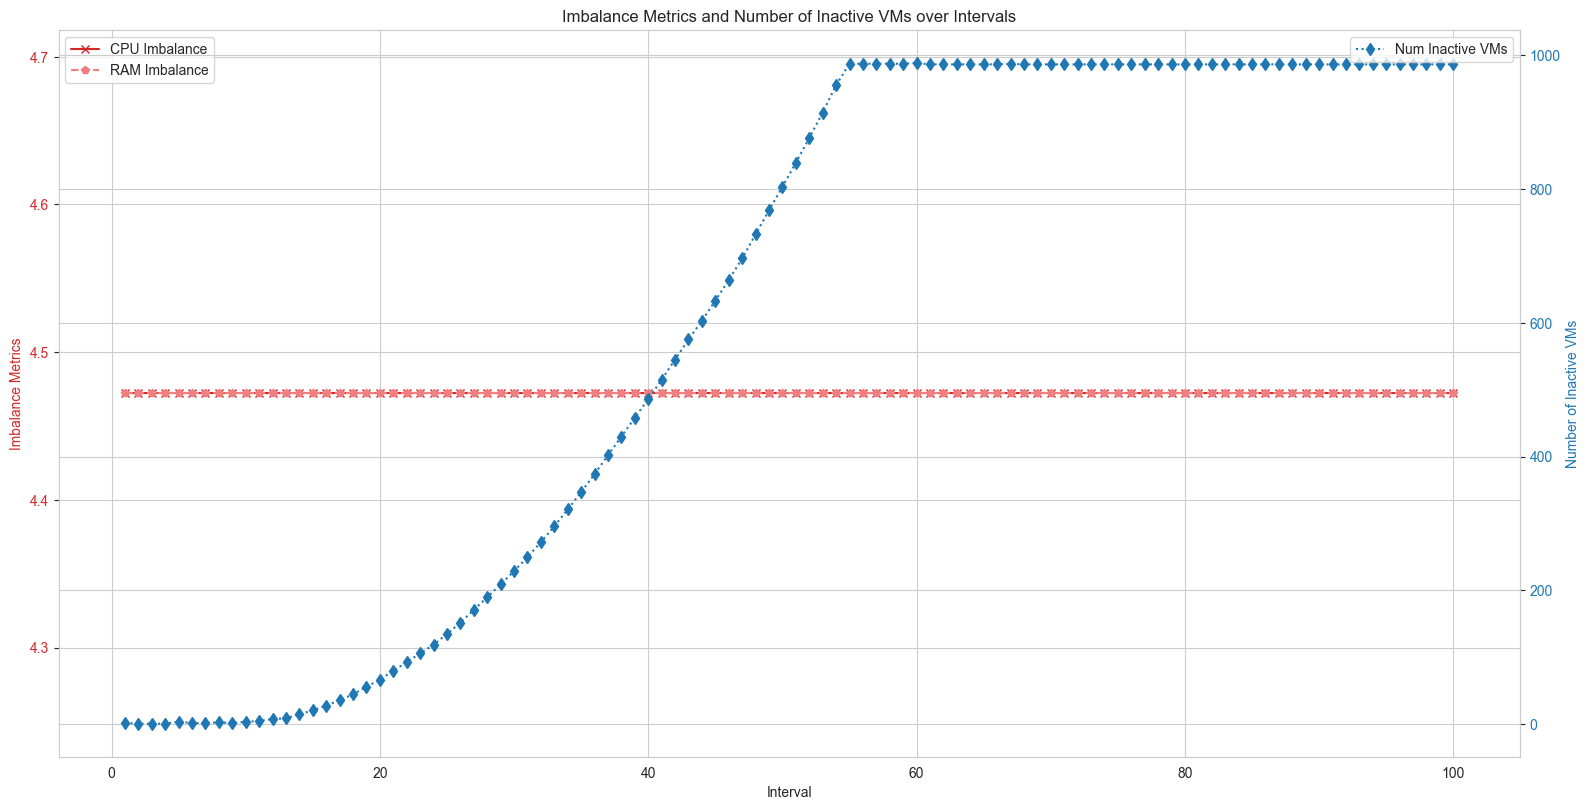

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast # For safely evaluating string-formatted lists

# %% [markdown]
# ## 1. Load Data
#
# Load the `mdql.csv` file into a pandas DataFrame.

# %%
try:
    df = pd.read_csv('metrics/nsga3.csv')
except FileNotFoundError:
    print("Error: 'mdql.csv' not found. Make sure the file is in the same directory as the notebook.")
    exit()

print("DataFrame Info:")
df.info()
print("\nFirst 5 rows of the DataFrame:")
print(df.head())
print("\nBasic statistics for numerical columns:")
print(df.describe())

# %% [markdown]
# ## 2. Data Preprocessing
#
# The columns `CPU_Utilization`, `Ram_Utilization`, and `Inactivevmids` are stored as strings representing lists. We need to convert them into actual Python lists and then derive meaningful numerical metrics from them.
#
# - For `CPU_Utilization` and `Ram_Utilization`: We will parse the lists and calculate the sum of utilizations for each interval to get a total utilization.
# - For `Inactivevmids`: We will parse the list and count the number of inactive VMs.

# %%
# Function to safely parse stringified lists
def parse_list_string(s):
    try:
        return ast.literal_eval(s)
    except (ValueError, SyntaxError):
        return [] # Return an empty list in case of parsing error

# Apply parsing and feature creation
df['CPU_Utilization_List'] = df['CPU_Utilization'].apply(parse_list_string)
df['Total_CPU_Utilization'] = df['CPU_Utilization_List'].apply(sum)

df['Ram_Utilization_List'] = df['Ram_Utilization'].apply(parse_list_string)
df['Total_Ram_Utilization'] = df['Ram_Utilization_List'].apply(sum)

df['Inactivevmids_List'] = df['Inactivevmids'].apply(parse_list_string)
df['Num_Inactive_VMs'] = df['Inactivevmids_List'].apply(len)

print("\nDataFrame with processed columns:")
print(df[['Interval', 'Power_Consumption', 'Total_CPU_Utilization', 'Total_Ram_Utilization', 'Num_Inactive_VMs', 'CPU_Imbalance', 'Ram_Imbalance']].head())

# %% [markdown]
# ## 3. Plotting Metrics
#
# We will now plot each relevant metric against the 'Interval' to observe trends.
# We are considering each of these metrics as an evaluation point for the underlying system/algorithms that generated this data.

# %%
# Set a nice style for the plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7) # Default figure size

# %% [markdown]
# ### 3.1 Power Consumption

# %%
plt.figure()
plt.plot(df['Interval'], df['Power_Consumption'], marker='o', linestyle='-', color='blue')
plt.title('Power Consumption over Intervals')
plt.xlabel('Interval')
plt.ylabel('Power Consumption (Units)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# %% [markdown]
# ### 3.2 Total CPU Utilization

# %%
plt.figure()
plt.plot(df['Interval'], df['Total_CPU_Utilization'], marker='s', linestyle='-', color='green')
plt.title('Total CPU Utilization over Intervals')
plt.xlabel('Interval')
plt.ylabel('Total CPU Utilization (Sum of list)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# %% [markdown]
# ### 3.3 Total RAM Utilization

# %%
plt.figure()
plt.plot(df['Interval'], df['Total_Ram_Utilization'], marker='^', linestyle='-', color='red')
plt.title('Total RAM Utilization over Intervals')
plt.xlabel('Interval')
plt.ylabel('Total RAM Utilization (Sum of list)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# %% [markdown]
# ### 3.4 Number of Inactive VMs

# %%
plt.figure()
plt.plot(df['Interval'], df['Num_Inactive_VMs'], marker='d', linestyle='-', color='purple')
plt.title('Number of Inactive VMs over Intervals')
plt.xlabel('Interval')
plt.ylabel('Number of Inactive VMs')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# %% [markdown]
# ### 3.5 CPU Imbalance

# %%
plt.figure()
plt.plot(df['Interval'], df['CPU_Imbalance'], marker='x', linestyle='-', color='orange')
plt.title('CPU Imbalance over Intervals')
plt.xlabel('Interval')
plt.ylabel('CPU Imbalance')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# %% [markdown]
# ### 3.6 RAM Imbalance

# %%
plt.figure()
plt.plot(df['Interval'], df['Ram_Imbalance'], marker='p', linestyle='-', color='brown')
plt.title('RAM Imbalance over Intervals')
plt.xlabel('Interval')
plt.ylabel('RAM Imbalance')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 4. Combined Metrics Plot (Optional)
#
# If metrics are on a similar scale or can be normalized, they can be plotted together.
# Here, we'll plot Power, CPU Util, and RAM Util on the same graph for a quick comparison,
# noting that their scales might differ significantly. For better comparison, normalization would be needed.

# %%
plt.figure(figsize=(16,8))

plt.plot(df['Interval'], df['Power_Consumption'], marker='o', linestyle='-', label='Power Consumption')
plt.plot(df['Interval'], df['Total_CPU_Utilization'] * 100, marker='s', linestyle='--', label='Total CPU Utilization (x100 for scale)') # Scaled for viz
plt.plot(df['Interval'], df['Total_Ram_Utilization'] * 100, marker='^', linestyle=':', label='Total RAM Utilization (x100 for scale)') # Scaled for viz

plt.title('Combined Metrics (Power, CPU, RAM Util.) over Intervals')
plt.xlabel('Interval')
plt.ylabel('Metric Value (Power in original units, Utilizations scaled)')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# %% [markdown]
# Another combined plot for Imbalance metrics and Number of Inactive VMs.

# %%
fig, ax1 = plt.subplots(figsize=(16, 8))

color = 'tab:red'
ax1.set_xlabel('Interval')
ax1.set_ylabel('Imbalance Metrics', color=color)
ax1.plot(df['Interval'], df['CPU_Imbalance'], color=color, linestyle='-', marker='x', label='CPU Imbalance')
ax1.plot(df['Interval'], df['Ram_Imbalance'], color='lightcoral', linestyle='--', marker='p', label='RAM Imbalance')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('Number of Inactive VMs', color=color)  # we already handled the x-label with ax1
ax2.plot(df['Interval'], df['Num_Inactive_VMs'], color=color, linestyle=':', marker='d', label='Num Inactive VMs')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('Imbalance Metrics and Number of Inactive VMs over Intervals')
plt.grid(True, which='both', axis='x', linestyle='--', linewidth=0.5) # Grid for x-axis
plt.show()

# %% [markdown]
# ## 5. Conclusion
#
# The plots above visualize the trends of various system metrics over the specified intervals.
# - Power consumption shows a ramp-up and then plateaus.
# - CPU and RAM utilization also increase and then stabilize, with CPU utilization reaching its peak much earlier than RAM utilization.
# - The number of inactive VMs increases significantly over time, suggesting more VMs are being provisioned or becoming idle.
# - CPU and RAM imbalance metrics remain relatively constant throughout the observation period.
#
# Further analysis could involve correlating these metrics, looking for specific events that cause changes, or comparing these trends against a baseline or another experimental setup.
# The "algorithms" being evaluated would be the underlying processes (e.g., VM placement, load balancing, power management strategies) that lead to these metric values.